In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Reshape
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
# Load data for images and labels

DATASET_PATH = 'data'

images = []
labels = []
    
for filename in os.listdir(DATASET_PATH):
    if filename.endswith('.png'):
        img_path = os.path.join(DATASET_PATH, filename)
        img = Image.open(img_path)
        images.append(np.array(img))
            
        label = filename[:-4]
        labels.append(label)

num_images = len(images)
print(f"Total number of images: {num_images}")

if num_images > 0:
    width, height = images[0].shape[:2]
    channels = images[0].shape[2] if images[0].ndim == 3 else 1
    print(f"Image dimensions (Width x Height): {width}x{height}")
    print(f"Image mode: {'Color' if channels == 3 else 'Grayscale'}")

Total number of images: 1040
Image dimensions (Width x Height): 50x200
Image mode: Grayscale


In [21]:
# Convert to grayscale and normalize
images = np.array(images)

if images.ndim == 4 and images.shape[3] == 3:  
    processed = np.dot(images[...,:3], [0.2989, 0.5870, 0.1140])
else:
    processed = images  
        
processed = np.array(processed) / 255.0
if processed.ndim == 3:
    processed = np.expand_dims(processed, axis=-1)

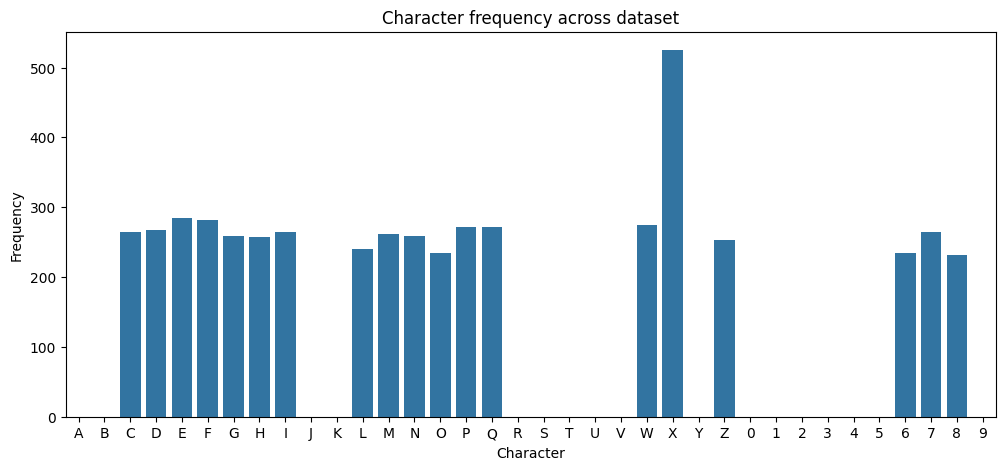

In [22]:
# Label Encoding 
char_set = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
    
le = LabelEncoder()
le.fit(list(char_set))
    
# Initialize array for one-hot encoded labels
encoded_labels = np.zeros((len(labels), 5, len(char_set)))
    
for i, label in enumerate(labels):
    chars = list(label.upper())  
        
    for j, char in enumerate(chars):
        char_idx = le.transform([char])[0]
        encoded_labels[i, j, char_idx] = 1

char_counts = encoded_labels.sum(axis=(0, 1))  

plt.figure(figsize=(12, 5))
sns.barplot(x=list(char_set), y=char_counts)
plt.xlabel("Character")
plt.ylabel("Frequency")
plt.title("Character frequency across dataset")
plt.show()


In [25]:
model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(50, 200, 1)))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(36*5, activation='softmax'))  # 36 classes, 5 characters


In [26]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    processed, encoded_labels, test_size=0.2, random_state=42
)


model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

# Train model
print("Training model...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
)

# Evaluate model
print("Evaluating model...")
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Make predictions on test set
predictions = model.predict(X_test)

# Convert predictions back to text
def decode_prediction(pred, encoder):
    """Convert one-hot prediction to text string"""
    pred_indices = np.argmax(pred, axis=-1)  # shape: (5,)
    return ''.join(encoder.inverse_transform(pred_indices))

# Display some sample predictions
print("\nSample predictions:")
for i in range(min(10, len(X_test))):
    actual = decode_prediction(y_test[i], label_encoder)
    predicted = decode_prediction(predictions[i], label_encoder)
    print(f"Actual: {actual}, Predicted: {predicted}, Correct: {actual == predicted}")

ValueError: Found input variables with inconsistent numbers of samples: [5, 1040]